In [1]:
# --- INSTALLS ---
!pip install "protobuf<4" -q

# --- CORE DATA & MATH ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import RegularPolygon, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.ndimage import gaussian_filter
from scipy.stats import pearsonr

# --- UTILITIES ---
import requests
from PIL import Image
from io import BytesIO
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
from IPython.display import display

# --- GOOGLE CLOUD & BIGQUERY ---
from google.cloud import bigquery
from google.colab import auth

# --- DEEP LEARNING ---
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# --- CONFIGURATION & BRANDING ---
%matplotlib inline
plt.style.use('fivethirtyeight')

PROJECT_ID = "mapping-nba-fouls"
DATASET_ID = "capstone_project"

BRAND_DARK = '#394146'
BRAND_WHITE = '#E6E6E6'
BRAND_GREY = '#8A8D8F'
FOUL_HIGH = '#CF142B'

# Team Branding Dictionary (Expanded for final leadboard)
TEAM_COLORS = {
    '1610612738': {'abbr': 'BOS', 'p': '#007A33', 's': '#BA9648'},
    '1610612744': {'abbr': 'GSW', 'p': '#1D428A', 's': '#FFC72C'},
    '1610612747': {'abbr': 'LAL', 'p': '#552583', 's': '#FDB927'},
    '1610612742': {'abbr': 'DAL', 'p': '#00538C', 's': '#B8C4CA'},
    '1610612760': {'abbr': 'OKC', 'p': '#007AC1', 's': '#EF3B24'},
    '1610612752': {'abbr': 'NYK', 'p': '#006BB6', 's': '#F58426'},
    '1610612748': {'abbr': 'MIA', 'p': '#98002E', 's': '#F9A01B'},
    '1610612755': {'abbr': 'PHI', 'p': '#006BB6', 's': '#ED174C'},
    '1610612749': {'abbr': 'MIL', 'p': '#00471B', 's': '#EEE1C6'}
}

print(f"🚀 Environment Ready. Libraries loaded at {datetime.now().strftime('%H:%M:%S')}")

🚀 Environment Ready. Libraries loaded at 07:41:06


In [2]:
def draw_court_accurate(ax, color='white', lw=1.75, paint_fill_color=None):
    """Draws an accurate NBA half-court with pro markings."""
    z = 10
    if paint_fill_color:
        ax.add_patch(patches.Rectangle((-80, -52.5), 160, 190, facecolor=paint_fill_color, alpha=0.15, zorder=1))

    # Boundary and Key
    ax.add_patch(patches.Rectangle((-250, -52.5), 500, 470, linewidth=lw, color=color, fill=False, zorder=z))
    ax.plot([-250, 250], [417.5, 417.5], color=color, lw=lw, zorder=z)
    ax.add_patch(patches.Rectangle((-80, -52.5), 160, 190, linewidth=lw, color=color, fill=False, zorder=z))
    ax.add_patch(patches.Rectangle((-60, -52.5), 120, 190, linewidth=lw, color=color, fill=False, zorder=z))

    # Arcs
    ax.add_patch(patches.Arc((0, 137.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, zorder=z))
    ax.add_patch(patches.Arc((0, 137.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color, linestyle='dashed', zorder=z))
    ax.add_patch(patches.Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False, zorder=z))

    # Hoop & Backboard
    ax.plot([-30, 30], [-12.5, -12.5], color=color, lw=lw*1.5, zorder=z)
    ax.add_patch(patches.Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color, zorder=z))

    # 3PT Line
    ax.plot([-220, -220], [-52.5, 89.477], color=color, lw=lw, zorder=z)
    ax.plot([220, 220], [-52.5, 89.477], color=color, lw=lw, zorder=z)
    ax.add_patch(patches.Arc((0, 0), 475, 475, theta1=22.13, theta2=157.87, linewidth=lw, color=color, zorder=z))

    return ax

print("🏀 Court engine initialized.")

🏀 Court engine initialized.


In [3]:
# --- 1. DATA FETCH (Lean & Pre-Engineered) ---
client = bigquery.Client(project=PROJECT_ID)

query = f"""
    SELECT
        CAST(s.player_id AS STRING) as player_id,
        p.full_name as player_name,
        s.season_id,
        s.loc_x,
        s.loc_y,
        CAST(s.is_foul_drawn AS INT64) as is_foul_drawn,
        CAST(s.is_made AS INT64) as is_made,
        p.height_inches,
        p.weight_lbs,
        p.experience_yrs, -- Using our pre-engineered feature
        CAST(p.ft_pct AS FLOAT64) as ft_pct
    FROM `{PROJECT_ID}.{DATASET_ID}.fct_shots` s
    LEFT JOIN `{PROJECT_ID}.{DATASET_ID}.dim_player_seasons` p
        ON s.player_id = p.player_id AND s.season_id = p.season_id
    WHERE s.loc_x IS NOT NULL AND s.loc_y IS NOT NULL
"""
df_raw = client.query(query).to_dataframe()

print(f"✅ Data fetched: {len(df_raw):,} rows.")

✅ Data fetched: 1,474,307 rows.


In [4]:
# --- 2. CLEANING & FILTERING (V3.6: No Imputation) ---

# 1. First, strip the year from season_id
df_raw['season_year'] = df_raw['season_id'].astype(str).str[-4:].astype(int)

# 2. DROP NULLS: If we don't know their height, weight, or FT%, they're out.
# This prevents the model from learning "average" noise.
df_clean = df_raw.dropna(subset=['height_inches', 'weight_lbs', 'experience_yrs', 'ft_pct']).copy()

# 3. VOLUME FILTER: 65+ shots AND 65+ fouls per season
volume_stats = df_clean.groupby(['player_id', 'season_year']).agg(
    total_shots=('is_foul_drawn', 'count'),
    total_fouls=('is_foul_drawn', 'sum')
).reset_index()

valid_seasons = volume_stats[(volume_stats['total_shots'] >= 65)]

# 4. DEFINE df_filtered (The merge ensures this variable exists)
df_filtered = df_clean.merge(valid_seasons[['player_id', 'season_year']], on=['player_id', 'season_year'], how='inner')

# 5. SCALING: Identity Features (0 to 1)
scaler = MinMaxScaler()
df_filtered[['height_scaled', 'weight_scaled', 'exp_scaled']] = scaler.fit_transform(
    df_filtered[['height_inches', 'weight_lbs', 'experience_yrs']]
)

# 6. HIGH-RESOLUTION FT% SCALING
# We use the filtered population's min and max to stretch the signal
ft_min = df_filtered['ft_pct'].min()
ft_max = df_filtered['ft_pct'].max()
df_filtered['ft_pct_scaled'] = (df_filtered['ft_pct'] - ft_min) / (ft_max - ft_min)

# Update our feature list
tab_cols = ['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']

print(f"✅ Preprocessing complete. '{len(df_filtered):,}' rows remain.")
print(f"🎯 FT% Signal Stretched: {ft_min:.1%} to {ft_max:.1%}")
print(f"Tabular features ready: {tab_cols}")

✅ Preprocessing complete. '1,209,471' rows remain.
🎯 FT% Signal Stretched: 14.3% to 100.0%
Tabular features ready: ['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']


In [5]:
# --- YEARLY POPULATION CHECK (V3.6) ---
# Count unique players per season in our final filtered dataset
yearly_counts = df_filtered.groupby('season_year')['player_id'].nunique().reset_index()
yearly_counts.columns = ['Season', 'Player Count']

# Sort by season to see the timeline clearly
yearly_counts = yearly_counts.sort_values('Season')

print("📊 UPDATED PLAYER POPULATION (No-Null Filter Applied)")
print("-" * 45)
display(yearly_counts)

# Summary Stats
total_samples = len(df_filtered.groupby(['player_id', 'season_year']))
avg_players = yearly_counts['Player Count'].mean()

print("-" * 45)
print(f"🚀 TOTAL UNIQUE PLAYER-SEASONS: {total_samples}")
print(f"📍 Average Players per Season:   {avg_players:.1f}")

📊 UPDATED PLAYER POPULATION (No-Null Filter Applied)
---------------------------------------------


,Season,Player Count
0,2019,344
1,2020,359
2,2021,369
3,2022,356
4,2023,360
5,2024,381


---------------------------------------------
🚀 TOTAL UNIQUE PLAYER-SEASONS: 2169
📍 Average Players per Season:   361.5


In [6]:
# --- 3. TENSORIZATION (V3.6: Stretched FT Signal) ---
grid_size = 20
extent = [-250, 250, -52.5, 417.5]
groups = df_filtered.groupby(['player_id', 'season_year'])

spatial_in, tabular_in, targets = [], [], []

print(f"📦 Packaging {len(groups)} high-quality player-seasons...")

for (pid, year), group in groups:
    # Spatial Channels
    shots, _, _ = np.histogram2d(group['loc_x'], group['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    makes, _, _ = np.histogram2d(group[group['is_made']==1]['loc_x'], group[group['is_made']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])

    # Target (Actual Fouls)
    fouls, _, _ = np.histogram2d(group[group['is_foul_drawn']==1]['loc_x'], group[group['is_foul_drawn']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])

    spatial_in.append(np.stack([shots, makes], axis=-1))
    # We pull from tab_cols which now includes 'ft_pct_scaled'
    tabular_in.append(group[tab_cols].iloc[0].values.astype(float))
    targets.append(np.expand_dims(fouls, -1))

X_spatial = np.array(spatial_in)
X_tab = np.array(tabular_in)
y_foul_map = np.array(targets)

# Maintain global scaling consistency
GLOBAL_SHOT_MAX = np.max(X_spatial[:,:,:,0])
X_spatial_scaled = X_spatial / GLOBAL_SHOT_MAX

# Train/Test Split (85/15)
X_sp_train, X_sp_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_spatial_scaled, X_tab, y_foul_map, test_size=0.15, random_state=42
)

print("-" * 30)
print(f"✅ Tensors Built with Stretched FT Signal")
print(f"Final Training Samples: {len(X_sp_train)}")

📦 Packaging 2169 high-quality player-seasons...
------------------------------
✅ Tensors Built with Stretched FT Signal
Final Training Samples: 1843


In [7]:
print(f"📊 Global Shot Max (Normalization Factor): {GLOBAL_SHOT_MAX}")

📊 Global Shot Max (Normalization Factor): 364.0


In [10]:
def build_whistle_net_v3_5(spatial_shape=(20, 20, 2), tabular_shape=(4,)):
    # --- BRANCH A: SPATIAL (The "Where") ---
    spatial_in = Input(shape=spatial_shape, name="Shot_Chart_Input")

    # Layer 1: Local clusters
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(spatial_in)
    x = layers.BatchNormalization()(x)

    # Layer 2: Spatial relationships
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Layer 3: High-level features
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # Spatial summary vector
    spatial_features = layers.GlobalMaxPooling2D()(x)

    # --- BRANCH B: TABULAR (The "Who") ---
    tabular_in = Input(shape=tabular_shape, name="Player_Traits_Input")
    y = layers.Dense(16, activation='relu')(tabular_in)
    y = layers.BatchNormalization()(y)

    # --- THE MERGE (Mid-Fusion) ---
    merged = layers.Concatenate()([spatial_features, y])

    # Decision Head
    z = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(merged)
    z = layers.Dropout(0.4)(z)

    # Output: 400 hexes (20x20)
    z = layers.Dense(20 * 20, activation='softplus')(z)

    output = layers.Reshape((20, 20, 1), name="Foul_Heatmap")(z)

    model = models.Model(inputs=[spatial_in, tabular_in], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008), loss='poisson')

    return model

print("🏗️ Model architecture 'build_whistle_net_v3_5' is now defined and ready.")

🏗️ Model architecture 'build_whistle_net_v3_5' is now defined and ready.


In [11]:
import tensorflow as tf

# --- CALLBACK DEFINITION V3.8 ---
callbacks = [
    # 1. Stop if val_loss doesn't improve for 15 epochs (Prevents overfitting)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # 2. Cut learning rate by half if we plateau for 8 epochs
    # This helps the model "fine-tune" the weights for those tricky role players
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

print("✅ Callbacks defined. Ready to train V3.8.")

# --- NOW RE-RUN TRAINING ---
foul_model = build_whistle_net_v3_5(tabular_shape=(4,))

history = foul_model.fit(
    x=[X_sp_train, X_tab_train],
    y=y_train,
    validation_data=([X_sp_test, X_tab_test], y_test),
    epochs=120,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

✅ Callbacks defined. Ready to train V3.8.
Epoch 1/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.2845 - val_loss: 0.1785 - learning_rate: 8.0000e-04
Epoch 2/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.1251 - val_loss: 0.1489 - learning_rate: 8.0000e-04
Epoch 3/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.1034 - val_loss: 0.1317 - learning_rate: 8.0000e-04
Epoch 4/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0948 - val_loss: 0.1145 - learning_rate: 8.0000e-04
Epoch 5/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0912 - val_loss: 0.0934 - learning_rate: 8.0000e-04
Epoch 6/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0884 - val_loss: 0.0908 - learning_rate: 8.0000e-04
Epoch 7/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0870 - val_loss: 0.0993 - learning_rate: 8.0000e-04
Epoch 8/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0860 - val_loss: 0.0865 - learning_rate: 8.0000e-04
Epoch 9/120
116/116 ━━━━━━━━━━

In [23]:
import numpy as np
from scipy.stats import pearsonr

# 1. Generate Predictions for the Test Set
y_pred = foul_model.predict([X_sp_test, X_tab_test], verbose=0)

# 2. Season Volume MAE & Global Bias
# Flatten the 20x20 grids into total foul counts per player-season
actual_totals = np.sum(y_test, axis=(1, 2, 3))
pred_totals = np.sum(y_pred, axis=(1, 2, 3))

mae_total = np.mean(np.abs(actual_totals - pred_totals))
bias = np.sum(actual_totals) / np.sum(pred_totals)

# 3. Spatial Correlation (Heatmap Accuracy)
# Calculate how well the predicted 'hot spots' match the actual 'hot spots'
corrs = []
for i in range(len(y_test)):
    # Flatten 20x20 grid to 400 points
    a = y_test[i].flatten()
    p = y_pred[i].flatten()

    # Only calculate correlation if there is variation in the data (avoiding div by zero)
    if np.std(a) > 0 and np.std(p) > 0:
        corr, _ = pearsonr(a, p)
        corrs.append(corr)

avg_corr = np.mean(corrs) if corrs else 0.0

# 4. Print the Final Audit
print("-" * 30)
print(f"📊 V3.8 LEAGUE BASELINE AUDIT")
print("-" * 30)
print(f"Poisson Loss (Val):   {history.history['val_loss'][-1]:.4f}")
print(f"Spatial Correlation:  {avg_corr:.2%}")
print(f"Season Volume MAE:    {mae_total:.2f} fouls")
print(f"Global Bias Factor:   {bias:.2f}x")
print("-" * 30)

------------------------------
📊 V3.8 LEAGUE BASELINE AUDIT
------------------------------
Poisson Loss (Val):   0.0773
Spatial Correlation:  83.06%
Season Volume MAE:    10.85 fouls
Global Bias Factor:   1.02x
------------------------------


In [12]:
# --- 5. V3.8 EVALUATION: THE ARTISAN BENCHMARK ---
# 1. Generate Predictions for the test set
y_pred = foul_model.predict([X_sp_test, X_tab_test])

# 2. Calculate MAE for the Test Set (League-wide)
# Rescale back from the 20x20 density to raw foul counts
actual_total = np.sum(y_test, axis=(1, 2, 3))
pred_total = np.sum(y_pred, axis=(1, 2, 3))
mae_league = np.mean(np.abs(actual_total - pred_total))

print(f"📉 League-Wide MAE (V3.8): {mae_league:.2f}")

# 3. IDENTIFY THE "SIGNATURE" LEADERS
# We'll run all 2,169 player-seasons through the model to see who breaks the baseline
all_preds = foul_model.predict([X_spatial_scaled, X_tab])
all_actuals = np.sum(y_foul_map, axis=(1, 2, 3))
all_predicted_totals = np.sum(all_preds, axis=(1, 2, 3))

# Create a Results DataFrame
results_v3_8 = []
for i, (pid, year) in enumerate(groups.groups.keys()):
    results_v3_8.append({
        'player_id': pid,
        'season': year,
        'actual_fouls': all_actuals[i],
        'expected_fouls': all_predicted_totals[i],
        'signature_delta': all_actuals[i] - all_predicted_totals[i]
    })

df_results = pd.DataFrame(results_v3_8)

# Map names back for the leaderboard
name_map = df_filtered.set_index('player_id')['player_name'].to_dict()
df_results['player_name'] = df_results['player_id'].map(name_map)

print("\n🏆 TOP SIGNATURE WHISTLES (V3.8 - League Baseline)")
print("-" * 50)
display(df_results.sort_values('signature_delta', ascending=False).head(10))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
📉 League-Wide MAE (V3.8): 10.85
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

🏆 TOP SIGNATURE WHISTLES (V3.8 - League Baseline)
--------------------------------------------------


,player_id,season,actual_fouls,expected_fouls,signature_delta,player_name
1009,1630183,2022,131.0,74.413475,56.586525,Jaden McDaniels
346,1628381,2022,150.0,103.812119,46.187881,John Collins
307,1628370,2024,110.0,64.496552,45.503448,Malik Monk
948,1630168,2022,163.0,118.973114,44.026886,Onyeka Okongwu
2080,203939,2022,138.0,95.376823,42.623177,Dwight Powell
838,1629655,2023,159.0,116.663239,42.336761,Daniel Gafford
1247,1630596,2022,141.0,99.267433,41.732567,Evan Mobley
211,1627751,2021,144.0,105.986099,38.013901,Jakob Poeltl
530,1628983,2023,98.0,60.282879,37.717121,Shai Gilgeous-Alexander
1506,200782,2019,121.0,83.757492,37.242508,P.J. Tucker


In [24]:
# --- 2024 SEASON SIGNATURE LEADERS ---
# Filter for 2024 and sort by Delta
top_15_2024 = df_results[df_results['season'] == 2024].sort_values('signature_delta', ascending=False).head(15)

print("🏆 2024 FOUL SIGNATURE DELTA: THE ELITE ARTISANS")
print("-" * 75)
display(top_15_2024[['player_name', 'actual_fouls', 'expected_fouls', 'signature_delta']])

🏆 2024 FOUL SIGNATURE DELTA: THE ELITE ARTISANS
---------------------------------------------------------------------------


,player_name,actual_fouls,expected_fouls,signature_delta
307,Malik Monk,110.0,64.496552,45.503448
1306,Jalen Duren,148.0,110.871872,37.128128
556,Jaren Jackson Jr.,138.0,101.416389,36.583611
1463,Bub Carrington,116.0,84.421303,31.578697
531,Shai Gilgeous-Alexander,101.0,71.939613,29.060387
411,Josh Hart,109.0,80.153534,28.846466
1469,Kyshawn George,119.0,91.724686,27.275314
548,Kevin Huerter,76.0,49.140800,26.859200
1948,Mason Plumlee,97.0,71.500473,25.499527
424,Dillon Brooks,105.0,79.906281,25.093719


In [19]:
def final_optimization_blueprint_v3_8(player_id, year, model, df_source):
    client = bigquery.Client(project=PROJECT_ID)
    target_sid = f"2{year}"
    season_title = f"{year-1}-{str(year)[-2:]}"

    # --- 1. DATA FETCH ---
    q_s = f"""SELECT loc_x, loc_y, team_id, CAST(is_foul_drawn AS INT64) as foul,
              CAST(is_made AS INT64) as made FROM `{PROJECT_ID}.{DATASET_ID}.fct_shots`
              WHERE player_id = '{player_id}' AND season_id = '{target_sid}'"""
    df_s = client.query(q_s).to_dataframe()
    if df_s.empty: return

    q_f = f"SELECT loc_x, loc_y FROM `{PROJECT_ID}.{DATASET_ID}.fct_fouls` WHERE player_id = '{player_id}' AND season_id = '{target_sid}'"
    df_f = client.query(q_f).to_dataframe()

    p_name, t_abbr, primary, secondary = "Unknown Player", "NBA", BRAND_GREY, FOUL_HIGH
    try:
        p_name = client.query(f"SELECT full_name FROM `{PROJECT_ID}.{DATASET_ID}.dim_player_seasons` WHERE player_id = '{player_id}' LIMIT 1").to_dataframe().iloc[0]['full_name']
        t_id_str = str(int(df_s['team_id'].dropna().iloc[0]))
        c_df = client.query(f"SELECT team_abbr, primary_color, secondary_color FROM `{PROJECT_ID}.{DATASET_ID}.dim_teams` WHERE team_id = '{t_id_str}'").to_dataframe()
        if not c_df.empty: t_abbr, primary, secondary = c_df.iloc[0]['team_abbr'], c_df.iloc[0]['primary_color'], c_df.iloc[0]['secondary_color']
    except: pass

    # --- 2. FEATURE & FT% LOGIC ---
    clean_df = df_source.reset_index().loc[:, ~df_source.reset_index().columns.duplicated()].copy()
    target_sid_int = int(target_sid)
    player_row = clean_df[(clean_df['player_id'] == player_id) & (clean_df['season_id'] == target_sid_int)]

    ft_pct = 0.77
    tab_in = np.array([0.5, 0.5, 0.5, 0.5])

    if not player_row.empty:
        tab_in = player_row[['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']].iloc[0].values.astype(float)
        ft_pct = player_row['ft_pct'].iloc[0]

    # --- 3. SPATIAL GRIDDING ---
    extent = [-250, 250, -52.5, 417.5]; grid_size = 20
    counts, x_edges, y_edges = np.histogram2d(df_s['loc_x'], df_s['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    made_grid, _, _ = np.histogram2d(df_s[df_s['made']==1]['loc_x'], df_s[df_s['made']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    foul_grid, _, _ = np.histogram2d(df_s['loc_x'], df_s['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]], weights=df_s['foul'])
    actual_pts_sum, _, _ = np.histogram2d(df_s['loc_x'], df_s['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]],
                                          weights=np.where(df_s['foul'] == 1, 2 * ft_pct, df_s['made'] * 2))

    # --- 4. PREDICTION (V3.8 Baseline) ---
    norm_val = 364.0
    spatial_input = np.expand_dims(np.stack([counts, made_grid], axis=-1) / norm_val, 0)
    pred_foul_counts = model.predict([spatial_input, np.expand_dims(tab_in, 0)], verbose=0)[0].reshape(20, 20)

    with np.errstate(divide='ignore', invalid='ignore'):
        ppa_grid = actual_pts_sum / counts
        delta_ppa_grid = ((foul_grid - pred_foul_counts) * 2 * ft_pct) / counts

    # --- 5. BINNING LOGIC (The "5-Size" Restoration) ---
    temp_fig = plt.figure(); hb = plt.hexbin(df_s['loc_x'], df_s['loc_y'], gridsize=grid_size, extent=extent); verts = hb.get_offsets(); plt.close(temp_fig)
    v_df = pd.DataFrame([{'v': v, 'n': counts[np.clip(np.digitize(v[0], x_edges)-1, 0, 19), np.clip(np.digitize(v[1], y_edges)-1, 0, 19)],
                          'ppa': ppa_grid[np.clip(np.digitize(v[0], x_edges)-1, 0, 19), np.clip(np.digitize(v[1], y_edges)-1, 0, 19)],
                          'delta': delta_ppa_grid[np.clip(np.digitize(v[0], x_edges)-1, 0, 19), np.clip(np.digitize(v[1], y_edges)-1, 0, 19)]}
                         for v in verts if counts[np.clip(np.digitize(v[0], x_edges)-1, 0, 19), np.clip(np.digitize(v[1], y_edges)-1, 0, 19)] >= 3])

    # YOUR ORIGINAL BINNING LOGIC RESTORED
    bins = sorted(list(set([2, max(3, np.percentile(v_df['n'], 25)), max(4, v_df['n'].median()),
                            max(5, np.percentile(v_df['n'], 75)), max(6, np.percentile(v_df['n'], 90)), v_df['n'].max()])))
    v_df['size_rank'] = pd.cut(v_df['n'], bins=bins, labels=False, include_lowest=True) + 1

    # --- 6. RENDER DASHBOARD ---
    fig = plt.figure(figsize=(14, 11), facecolor=BRAND_DARK)
    fig.text(0.02, 0.97, "CRITICAL SECTION // OPTIMIZATION BLUEPRINT", color=BRAND_WHITE, fontsize=28, fontweight='bold', va='top')
    fig.text(0.02, 0.935, f"{p_name.upper()} // {t_abbr} // {season_title} SCORING ECONOMY", color=BRAND_GREY, fontsize=14, va='top')

    ax_court = fig.add_axes([0.0, 0.07, 0.69, 0.9])
    ax_court.set_facecolor(BRAND_DARK); ax_court.set_aspect('equal'); ax_court.set_xlim(-260, 260); ax_court.set_ylim(-65, 480); ax_court.axis('off')

    div_cmap = plt.cm.RdBu_r; MAX_R = 25.0 / np.sqrt(3)
    for _, row in v_df.iterrows():
        rad = (0.08 + 0.82 * (row['size_rank'] / len(bins[:-1]))) * MAX_R
        ax_court.add_patch(RegularPolygon(row['v'], 6, radius=rad, facecolor=div_cmap(np.clip((row['ppa']-0.6)/0.96, 0, 1)),
                                         edgecolor=div_cmap(np.clip((row['delta']+0.15)/0.3, 0, 1)), linewidth=2.5, alpha=0.95, zorder=3))

    if not df_f.empty:
        fcnts, xedges_f, yedges_f = np.histogram2d(df_f['loc_x'], df_f['loc_y'], bins=40, range=[[-250, 250], [-52.5, 417.5]])
        smoothed = gaussian_filter(fcnts, sigma=1.5)
        X, Y = np.meshgrid(np.linspace(-250, 250, 40), np.linspace(-52.5, 417.5, 40))
        ax_court.contour(X, Y, smoothed.T, levels=np.percentile(smoothed[smoothed>0], [75, 90, 98]), colors=secondary, linewidths=0.75, alpha=0.8, zorder=6)

    draw_court_accurate(ax_court, color=primary, lw=2.0, paint_fill_color=primary)

    # UI PANELS (RESTORED)
    ax_stats = fig.add_axes([0.71, 0.62, 0.2, 0.18])
    ax_stats.set_facecolor(BRAND_DARK); ax_stats.axis('off'); ax_stats.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor=secondary, lw=1.5, transform=ax_stats.transAxes))
    ax_stats.text(0.5, 0.85, "OPTIMIZATION STATS", color=BRAND_WHITE, fontsize=12, weight='bold', ha='center', transform=ax_stats.transAxes)
    ax_stats.text(0.05, 0.60, f"Total Shots Map: {int(v_df['n'].sum()):,}", color=BRAND_WHITE, transform=ax_stats.transAxes)
    ax_stats.text(0.05, 0.40, f"Avg PPA: {actual_pts_sum.sum()/counts.sum():.2f}", color=BRAND_WHITE, transform=ax_stats.transAxes)
    ax_stats.text(0.05, 0.05, "Contours: Foul Density Overlay", color=secondary, style='italic', transform=ax_stats.transAxes)

    ax_leg = fig.add_axes([0.68, 0.21, 0.25, 0.36])
    ax_leg.set_facecolor(BRAND_DARK); ax_leg.set_aspect('equal'); ax_leg.axis('off'); ax_leg.set_xlim(0, 150); ax_leg.set_ylim(0, 200)
    ax_leg.add_patch(Rectangle((0, 5), 150, 195, fill=False, edgecolor=secondary, lw=1.5))
    ax_leg.text(75, 185, "SHOT VOLUME", color=BRAND_WHITE, weight='bold', size=11, ha='center')

    q_stats = v_df.groupby('size_rank')['n'].agg(['min', 'max']).sort_index()
    num_bins = len(bins[:-1])
    y_sp = 135 / max(1, (num_bins-1))
    for i, rank in enumerate(q_stats.index):
        label = f"{int(q_stats.loc[rank]['min'])}-{int(q_stats.loc[rank]['max'])} shots"
        if i == num_bins - 1: label = f"{int(q_stats.loc[rank]['min'])}+ shots"
        ax_leg.add_patch(RegularPolygon((45, 150-i*y_sp+15), 6, radius=(0.08+0.82*(rank/num_bins))*MAX_R, facecolor=secondary, edgecolor=primary, linewidth=2.0))
        ax_leg.text(80, 150-i*y_sp+15, label, color=BRAND_WHITE, size=11)

    try:
        img = Image.open(BytesIO(requests.get(f"https://cdn.nba.com/headshots/nba/latest/1040x760/{player_id}.png").content)).convert("RGBA")
        ax_photo = fig.add_axes([0.65, 0.0, 0.32, 0.20]); ax_photo.axis('off'); ax_photo.imshow(img, aspect='equal')
    except: pass

    for i, (lab, n_range) in enumerate([('HEX FILL: TOTAL EFFICIENCY (PPA)', (0.6, 1.5)), ('HEX BORDER: FOUL SIGNATURE DELTA', (-0.15, 0.15))]):
        cb_ax = fig.add_axes([0.02 + i*0.32, 0.02, 0.28, 0.015])
        fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(*n_range), cmap=div_cmap), cax=cb_ax, orientation='horizontal')
        cb_ax.set_xlabel(lab, color=BRAND_WHITE, size=10, weight='bold')

    plt.show()

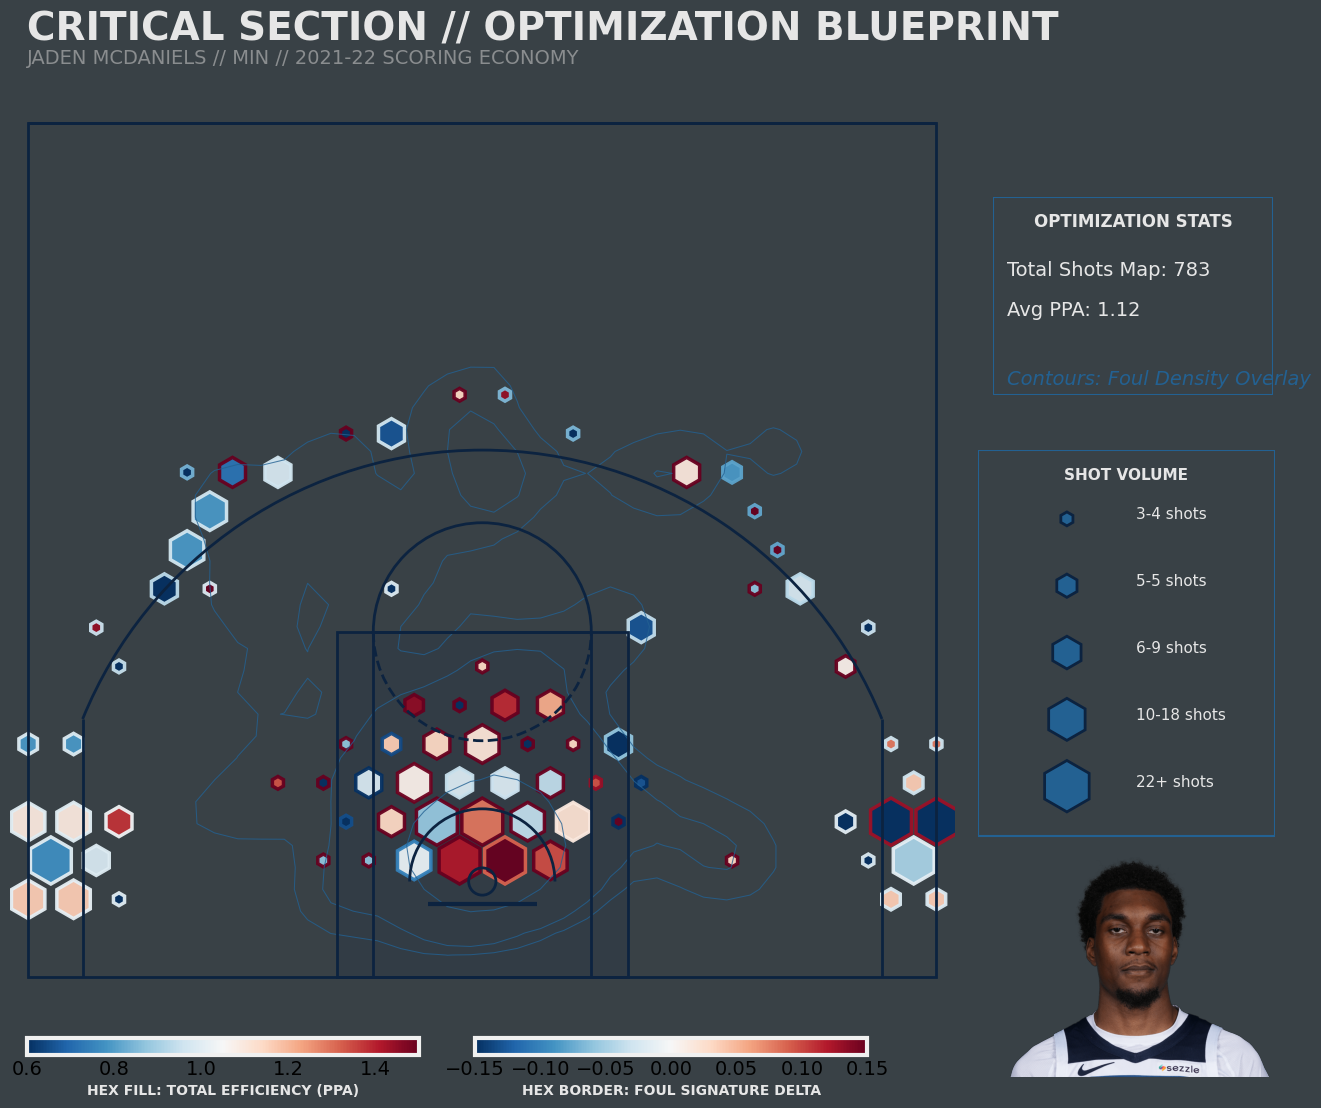

In [20]:
# View the surprise leader with ALL visual elements restored
final_optimization_blueprint_v3_8(player_id="1630183", year=2022, model=foul_model, df_source=df_filtered)

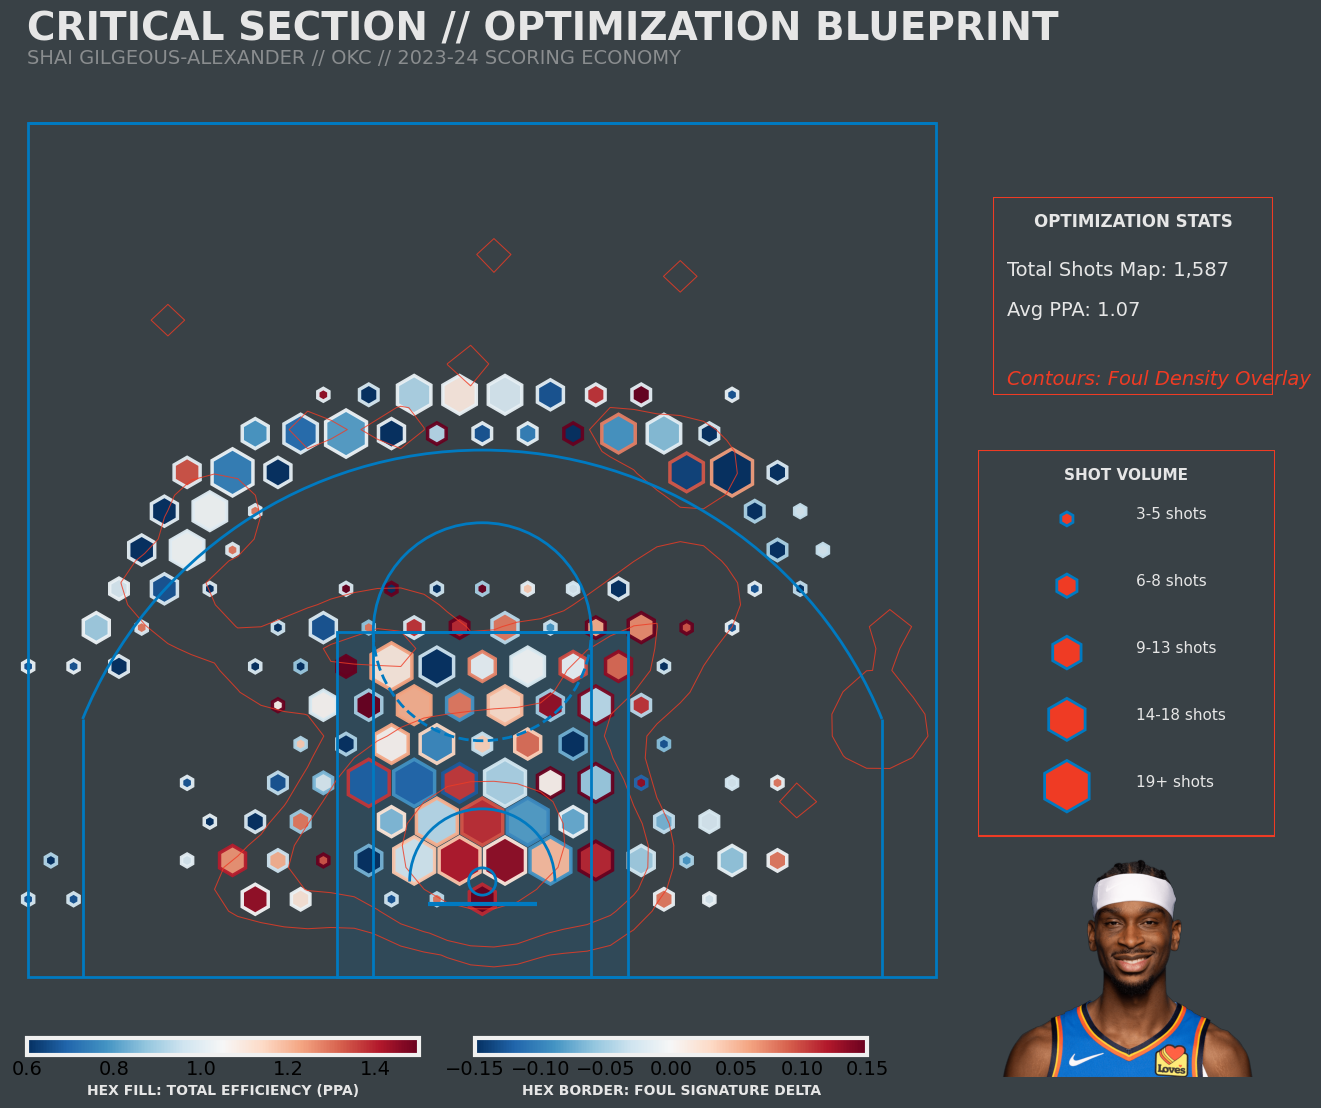

In [21]:
# --- RUNNING THE BLUEPRINT FOR SGA 2023-24 ---
# player_id: 1628983 (Shai Gilgeous-Alexander)
# year: 2024 (represents the 2023-24 season)

final_optimization_blueprint_v3_8(
    player_id="1628983",
    year=2024,
    model=foul_model,
    df_source=df_filtered
)

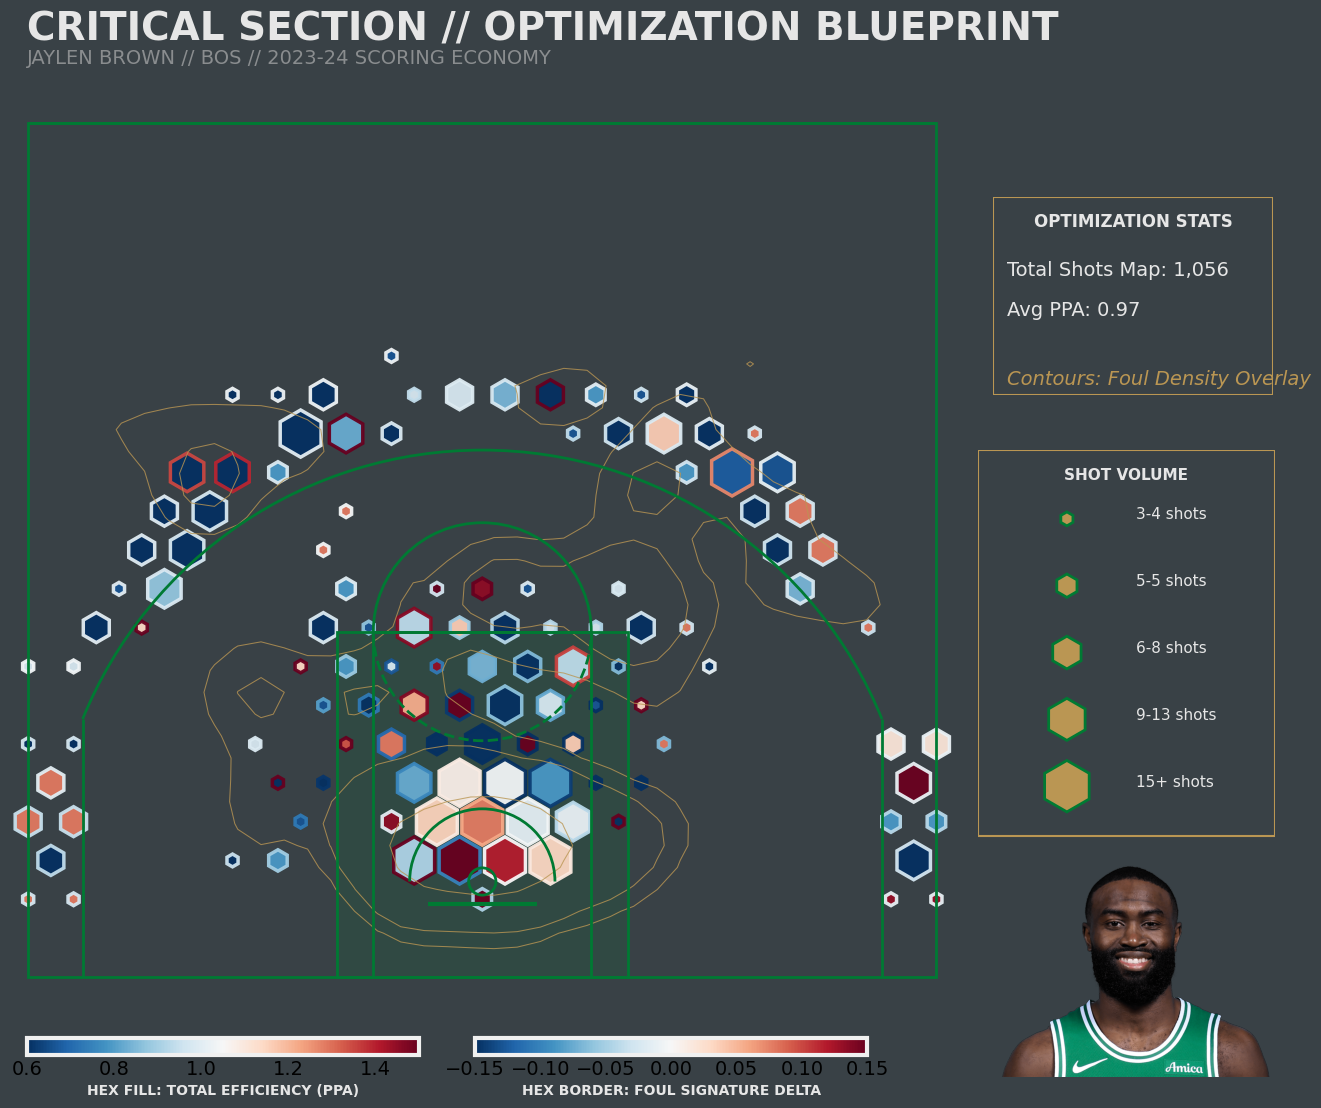

In [22]:
# --- RUNNING THE BLUEPRINT FOR JAYLEN BROWN 2023-24 ---
# player_id: 1627759 (Jaylen Brown)
# year: 2024 (represents the 2023-24 season)

final_optimization_blueprint_v3_8(
    player_id="1627759",
    year=2024,
    model=foul_model,
    df_source=df_filtered
)

In [ ]:
# --- GENERATE THE V3.6 HIGH-RES LEADERBOARD ---
print("🏆 Calculating the High-Res Whistle Artisans (V3.6)...")

all_preds = foul_model.predict([X_spatial_scaled, X_tab], verbose=0)

final_results = []
for i, (idx, group) in enumerate(df_filtered.groupby(['player_id', 'season_year'])):
    actual = y_foul_map[i].sum()
    expected = all_preds[i].sum()
    delta = actual - expected

    final_results.append({
        'Player': group['player_name'].iloc[0],
        'Season': group['season_year'].iloc[0],
        'FT%': f"{group['ft_pct'].iloc[0]:.1%}",
        'Actual': int(actual),
        'Expected': round(expected, 1),
        'Signature Delta': round(delta, 1),
        'Whistle Boost %': round((delta / expected) * 100, 1)
    })

high_res_leaderboard = pd.DataFrame(final_results).sort_values('Signature Delta', ascending=False)

print("\n🔥 THE 2024-25 SIGNATURE WHISTLE TOP 10")
display(high_res_leaderboard[high_res_leaderboard['Season'] == 2024].head(10))

🏆 Calculating the High-Res Whistle Artisans (V3.6)...

🔥 THE 2024-25 SIGNATURE WHISTLE TOP 10


,Player,Season,FT%,Actual,Expected,Signature Delta,Whistle Boost %
415,Jalen Duren,2024,66.9%,148,104.400002,43.6,41.7
196,Jaren Jackson Jr.,2024,78.1%,138,95.699997,42.3,44.3
456,Bub Carrington,2024,81.2%,116,80.500000,35.5,44.2
460,Kyshawn George,2024,75.3%,119,86.400002,32.6,37.7
7,Karl-Anthony Towns,2024,82.9%,131,100.900002,30.1,29.8
574,Draymond Green,2024,68.7%,117,87.699997,29.3,33.4
458,Donovan Clingan,2024,59.6%,130,101.300003,28.7,28.4
100,Malik Monk,2024,86.5%,110,81.900002,28.1,34.3
148,Josh Hart,2024,77.6%,109,81.300003,27.7,34.0
49,Kris Dunn,2024,68.2%,102,77.000000,25.0,32.5


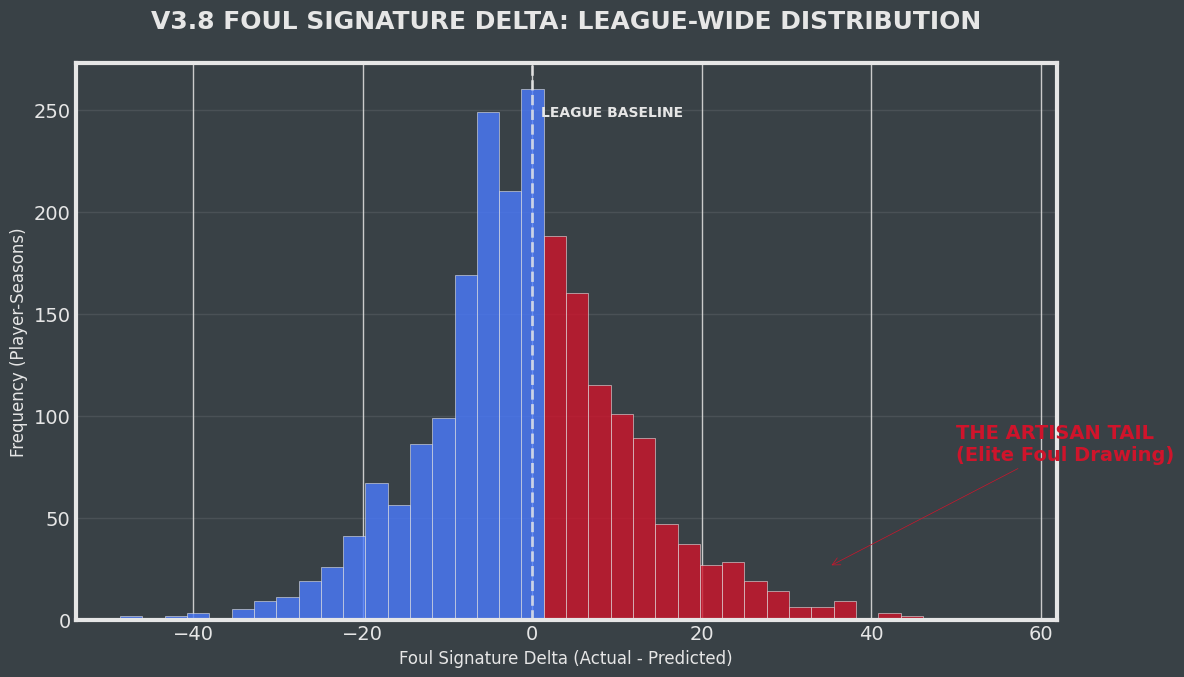

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 1. SETUP THE BRANDED CANVAS
fig, ax = plt.subplots(figsize=(12, 7), facecolor=BRAND_DARK)
ax.set_facecolor(BRAND_DARK)

# 2. PLOT THE DATA
deltas = df_results['signature_delta']
# Using 40 bins to catch the "Artisan Tails"
n, bins, patches = ax.hist(deltas, bins=40, color=BRAND_GREY, alpha=0.8, edgecolor=BRAND_WHITE, linewidth=0.5)

# Colorize: Red for Artisans (Positive Delta), Blue for Efficient Finishers (Negative Delta)
for bin_value, patch in zip(bins, patches):
    if bin_value > 0:
        patch.set_facecolor(FOUL_HIGH) # Our 'Surprise' color
    else:
        patch.set_facecolor('#4B7BFF') # Standard Efficiency

# 3. ADD BASELINE & ANNOTATIONS
ax.axvline(0, color=BRAND_WHITE, linestyle='--', linewidth=2, alpha=0.8)
ax.text(1, n.max()*0.95, "LEAGUE BASELINE", color=BRAND_WHITE, fontweight='bold', fontsize=10)

# Statistical Markers
mean_val = deltas.mean()
ax.annotate('THE ARTISAN TAIL\n(Elite Foul Drawing)', xy=(35, n.max()*0.1), xytext=(50, n.max()*0.3),
            color=FOUL_HIGH, weight='bold', arrowprops=dict(arrowstyle='->', color=FOUL_HIGH))

# 4. FORMATTING
ax.set_title("V3.8 FOUL SIGNATURE DELTA: LEAGUE-WIDE DISTRIBUTION", color=BRAND_WHITE, fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel("Foul Signature Delta (Actual - Predicted)", color=BRAND_WHITE, fontsize=12)
ax.set_ylabel("Frequency (Player-Seasons)", color=BRAND_WHITE, fontsize=12)
ax.tick_params(colors=BRAND_WHITE)
for spine in ax.spines.values(): spine.set_color(BRAND_WHITE)
ax.grid(axis='y', alpha=0.1, color=BRAND_WHITE)

plt.tight_layout()
plt.show()